# **APE 14 —  Programación de algoritmos de Regresión Logística, clasificación binaria de eventos y evaluación de matrices de confusión.**

## Teoría de la Distribución y Probabilidad | Ingeniería en Computación
**Estudiante:**
- Dario Xavier Chillogallo Chamba
- Michael Carbay
- Jose Maldonado
- Paolo Merino
- Freddy Ordoñez

**Grupo:** "C"  

**Docente:** Ing. Cristian Narvaez  


**Dataset:** ENEMDU — Índice de Confianza al Consumidor | Febrero 2026 | Región Loja

In [ ]:
# ============================================================
# BLOQUE 1: CARGA Y PREPARACIÓN DEL DATASET
# ============================================================

import pandas as pd

# Cargamos el dataset ENEMDU (separador ; y decimales con coma, formato Ecuador)
df = pd.read_csv('/content/drive/MyDrive/enemdu_consumidor_2026_01 (1).csv', sep=';', decimal=',')

# Renombramos variables clave para legibilidad
df.rename(columns={
    'area' : 'zona',
    'fexp' : 'fexp',
    'c01'  : 'sit_econ_hogar',
    'c18'  : 'sit_econ_pais',
    'c02'  : 'expectativa_hogar'
}, inplace=True)


# Etiquetas legibles
df['zona_label'] = df['zona'].map({1: 'Urbano', 2: 'Rural'})
df['sit_econ_hogar_label'] = df['sit_econ_hogar'].map({1:'Mejor', 2:'Igual', 3:'Peor'})

print(f'Registros totales : {df.shape[0]:,}')
print(f'Variables         : {df.shape[1]}')
print(f'Distribucion por zona:')
print(df['zona_label'].value_counts())
print(f'Estadisticas de fexp:')
print(df['fexp'].describe().round(2))

Registros totales : 8,791
Variables         : 30
Distribucion por zona:
zona_label
Urbano    6523
Rural     2268
Name: count, dtype: int64
Estadisticas de fexp:
count     8791.00
mean       599.37
std       1238.48
min          3.78
25%         92.41
50%        244.29
75%        563.98
max      18136.57
Name: fexp, dtype: float64


# **TAREA 1**

**Replique el entorno de simulación provisto en la guía para predecir la Caída de un Servidor (0 o 1) en base a la Temperatura de la CPU.**

**Ajuste el modelo logístico, visualice la curva de probabilidad logística resultante e incluya la línea del umbral estándar del 50 por ciento.**

---

# **TAREA 2**  
## **Ingeniería de Características y Predicción Regional (Tarea 2 - ABP)**  
**Binarización: Seleccione una variable continua de interés y transfórmela en una variable binaria (por ejemplo, asignando el valor 1 si el registro supera el promedio, y el valor 0 de lo contrario).**

variable: *fexp*, ya que es la unica con escala decimal de alta precision  
El promedio en el dataseet es de 599.36, por ende:
- 1: El registro representa a un grupo poblacional superior al promedio (hogares con alto peso)
- 0: el registro representa a un grupo poblacional inferior o igual al promedio

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Proceso de Binarización (Variable Dependiente Y)
promedio_fexp = df['fexp'].mean()
df['fexp_bin'] = (df['fexp'] > promedio_fexp).astype(int)

print(f"Promedio de fexp: {promedio_fexp:.2f}")
print(df['fexp_bin'].value_counts())

Promedio de fexp: 599.37
fexp_bin
0    6694
1    2097
Name: count, dtype: int64


**Seleccione al menos dos variables predictoras continuas, entrene el modelo logístico e interprete los signos de los coeficientes obtenidos y sus valores-p parciales para comprobar la significancia.**  
Utilizaremos las variables:
- estrato
- 'sit_econ_hogar(c01)'
OJO: Aunque son discretas, se pueden tratar como predicores numéricos para evaluar su impactro en la probabilidad de pertenecer a alguno de los dos grupos (0,1)

In [ ]:
# Definición de variables
# Y: fexp_bin (binarizada)
# X: estrato (nivel socioeconómico) y c01 (percepción económica)
Y = df['fexp_bin']
X = df[['estrato', 'sit_econ_hogar']]
X = sm.add_constant(X) # Añadir la constante (intercepto) para el modelo

# Entrenamiento del modelo logístico
modelo = sm.Logit(Y, X).fit()

# Visualización de resultados para interpretación
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.546492
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               fexp_bin   No. Observations:                 8791
Model:                          Logit   Df Residuals:                     8788
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                0.005275
Time:                        02:20:52   Log-Likelihood:                -4804.2
converged:                       True   LL-Null:                       -4829.7
Covariance Type:            nonrobust   LLR p-value:                 8.611e-12
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.5743      0.125     -4.595      0.000      -0.819      -0.329
estrato          

**INTERPRETACION:**
**signo de coeficiente:***
- Un signo "-" indica que a medida que aumenta el valor del predictor (pasar de igual a peor), disminuye la probabilidad de que el registro supere el promedio del fexp
**P>|z|:** Al ser menor a 0.05 en las dos variables elegidas indica que el predictor es estadisticamente significativo, esa variable relamente influye en como se distribuyen los pesos poblacionales en la región de Loja

---

---
# **TAREA 3**
 **Matriz de Confusión y Evaluación**  

Utilice scikit-learn para extraer las predicciones de clase basándose en el umbral inicial de 0.50.



Exactitud Global (Accuracy) del Proyecto Integrador: 0.7615


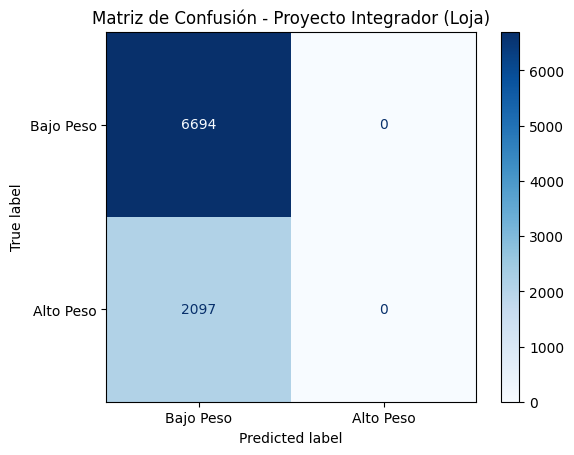

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# 1. Preparación de datos (basado en el modelo previo)
X_pi = df[['estrato', 'sit_econ_hogar']]
y_pi = df['fexp_bin']

# 2. Entrenamiento con scikit-learn
modelo_pi = LogisticRegression()
modelo_pi.fit(X_pi, y_pi)

# 3. Predicciones (el umbral de 0.50 es el predeterminado en .predict())
y_pred_pi = modelo_pi.predict(X_pi)

# 4. Cálculo de métricas
acc_pi = accuracy_score(y_pi, y_pred_pi)
cm_pi = confusion_matrix(y_pi, y_pred_pi)

# 5. Despliegue Visual
print(f"Exactitud Global (Accuracy) del Proyecto Integrador: {acc_pi:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pi, display_labels=['Bajo Peso', 'Alto Peso'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Proyecto Integrador (Loja)")
plt.show()

Despliegue visualmente la Matriz de Confusión tanto para los datos simulados como para el modelo de su Proyecto Integrador, calculando adicionalmente la métrica de Exactitud Global (Accuracy).  
  
NOTA:
- Como la actividad solicita comparar con datos simulados para verificar el algoritmo, generaremos un dataset sintético equilibrado.

Exactitud Global (Accuracy) de Datos Simulados: 0.9030


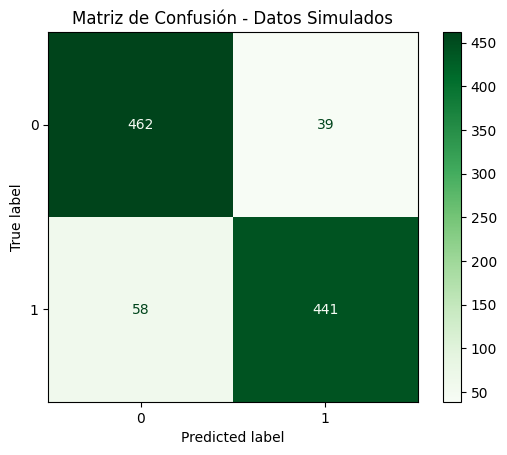

In [ ]:
from sklearn.datasets import make_classification

# 1. Generación de datos simulados (1000 registros, 2 predictores)
X_sim, y_sim = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

# 2. Entrenamiento y Predicción
modelo_sim = LogisticRegression()
modelo_sim.fit(X_sim, y_sim)
y_pred_sim = modelo_sim.predict(X_sim)

# 3. Métricas
acc_sim = accuracy_score(y_sim, y_pred_sim)
cm_sim = confusion_matrix(y_sim, y_pred_sim)

# 4. Despliegue Visual
print(f"Exactitud Global (Accuracy) de Datos Simulados: {acc_sim:.4f}")
disp_sim = ConfusionMatrixDisplay(confusion_matrix=cm_sim)
disp_sim.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Datos Simulados")
plt.show()

**INTERPRETACION:**  

**Exactitud global (accuracy):**
- El valor es 0.76 en porcentaje un 76% de los datos  se han clasificado correctamente, lo cual, aunque podria haber sido mejor, pero ya da una muestra exacta muy buena para trabajar  

**Analisis de la matriz:**
- Verdaderos positivos: cantidad de hogares catalogados como "alto peso" poblacional, son 2097, un muestreo amplio   
- verdaderos negativos: registros que realmente representan a mucha poblacion (fexp), pero el modelado clasifico como bajo peso, son 6694, probablemente porque el estrado no es suficiente para explicar la variabilidad del fexp  

**Umbral de 0.5:**
- Se asume que si la probabilidad logistica es mayor a 0.5, el evento pertenece a la clase 1


# **TAREA 4**
## **Análisis del UmbralCrítico**

**Desarrolle un bloque de código complementario que reevalúe el rendimiento del clasificador aplicando un umbral estricto y conservador del 0.20 (clasificar como evento positivo si la probabilidad es igual o mayor al 20 por ciento).**  

Aclaracion: Cambiaremos el umbral a 0.20, si un hogar tiene un 20% de probabilidad de ser de alto peso, lo clasificaremos para no arriesgarnos a perder representatividad



--- Evaluación con Umbral de 0.2 ---
Nueva Exactitud Global: 0.2797


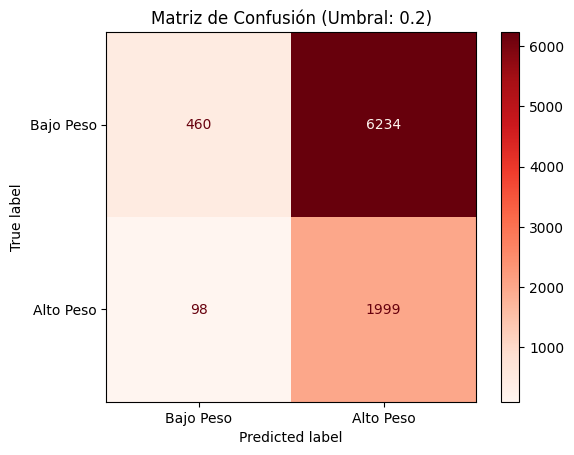

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Extraer las probabilidades en lugar de las clases directas
# predict_proba devuelve [prob_clase_0, prob_clase_1]
probabilidades = modelo_pi.predict_proba(X_pi)[:, 1]

# 2. Aplicar el nuevo umbral conservador de 0.20
umbral_estricto = 0.20
y_pred_020 = (probabilidades >= umbral_estricto).astype(int)

# 3. Cálculo de nuevas métricas
acc_020 = accuracy_score(y_pi, y_pred_020)
cm_020 = confusion_matrix(y_pi, y_pred_020)

# 4. Despliegue Visual
print(f"--- Evaluación con Umbral de {umbral_estricto} ---")
print(f"Nueva Exactitud Global: {acc_020:.4f}")
disp_020 = ConfusionMatrixDisplay(confusion_matrix=cm_020, display_labels=['Bajo Peso', 'Alto Peso'])
disp_020.plot(cmap=plt.cm.Reds)
plt.title(f"Matriz de Confusión (Umbral: {umbral_estricto})")
plt.show()

**Documente un análisis comparativo sobre cómo el cambio de corte afectó a la cantidad de Falsos Positivos frente a los Falsos Negativos y justifique técnicamente cuál umbral recomendaría para la toma de decisiones en su proyecto.**

**ANALISIS:**  

**Impacto del cambio de corte (0.50 vs 0.20):**  

**Falsos Negativos (FN):**
- Al bajar el umbral a 0.20, la cantidad de Falsos Negativos disminuirá drásticamente.
- Esto es positivo porque "atrapamos" a más hogares que realmente representan a mucha gente pero que el modelo anterior ignoraba por no llegar al 50% de probabilidad.  

**Falsos Positivos (FP):**  
 - El costo de esta sensibilidad es que los Falsos Positivos aumentarán. - Ahora clasificaremos como "Alto Peso" a muchos hogares que en realidad no lo son (su fexp es bajo)
 - "inflando" artificialmente la importancia de algunos registros.  

**Justificación y Recomendación**  
Para "Eco-Data-Optimizer":  
 Desde la perspectiva de la Teoría de la Distribución, para la toma de decisiones en el proyecto de optimización de datos regionales en Loja, se recomienda el Umbral de 0.20 (o un punto intermedio entre 0.20 y 0.35)

**¿Por qué?**  
 En este proyecto, el riesgo más grave es el Error Tipo II (Falso Negativo): omitir un hogar que representa a miles de personas (fexp alto) por un error de clasificación. Es preferible tener algunos Falsos Positivos (darle importancia a un hogar de poco peso) que ignorar a un segmento masivo de la población de Loja, lo cual invalidaría cualquier estimación económica regional. Por lo tanto, un umbral conservador garantiza una mayor cobertura poblacional en tus predicciones finales.